# Description
This is an experimental Notebook, using all available transaction data

In [1]:
import pandas as pd
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

### Creating one entry for revenue per state and date

In [2]:
cols = ["Shipping Address State", "date", "ppt", "tavg", "Revenue"]
data = pd.read_csv("./data/data_combined_full.csv", usecols=cols)

data = data.sort_values("date", ascending=True)

data_grouped = data.groupby(["date", "Shipping Address State"]).agg({"Revenue": "sum"})


data_grouped["Revenue"] = data_grouped["Revenue"].round(2)

data_grouped.reset_index(["date", "Shipping Address State"], inplace=True)



In [3]:
df_Cfa = data_grouped[data_grouped["Shipping Address State"].isin(["SD", "NE", "KS", "IA", "IL", "IN", "OH", "PA", "NY", "CT", "MA", "RI"])]
df_Cfa

,date,Shipping Address State,Revenue
5,2017-01-01,CT,0.0
9,2017-01-01,IA,0.0
11,2017-01-01,IL,0.0
12,2017-01-01,IN,0.0
13,2017-01-01,KS,0.0
...,...,...,...
122671,2023-12-31,NY,0.0
122672,2023-12-31,OH,0.0
122675,2023-12-31,PA,0.0
122676,2023-12-31,RI,0.0


### Creating one entry for revnue per date

In [4]:
data = df_Cfa.sort_values("date", ascending=True)

data_grouped_date = data.groupby(["date"]).agg({"Revenue": "sum"})


data_grouped_date["Revenue"] = data_grouped_date["Revenue"].round(2)

data_grouped_date.reset_index("date", inplace=True)

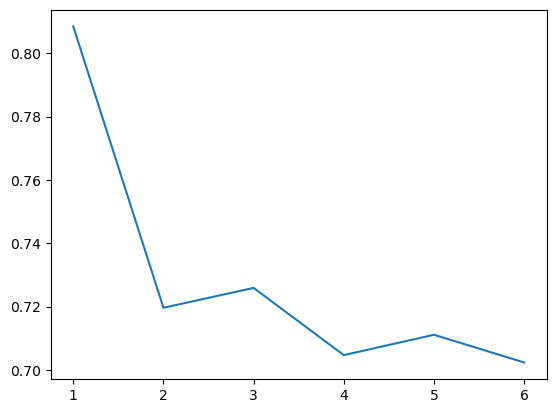

In [5]:
acf_values = acf(data_grouped_date["Revenue"], nlags=6)

plt.plot(range(1, len(acf_values)), acf_values[1:])

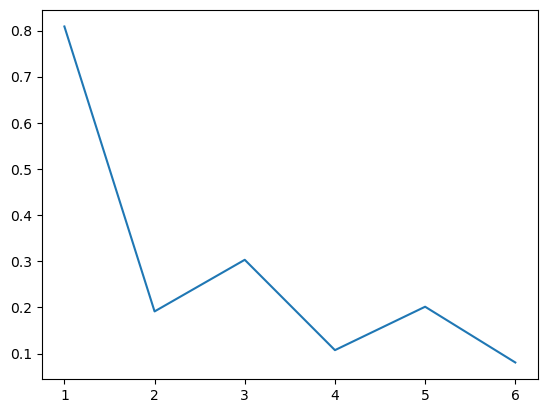

In [6]:
pacf_values = pacf(data_grouped_date["Revenue"], nlags=6)
plt.plot(range(1, len(pacf_values)), pacf_values[1:])

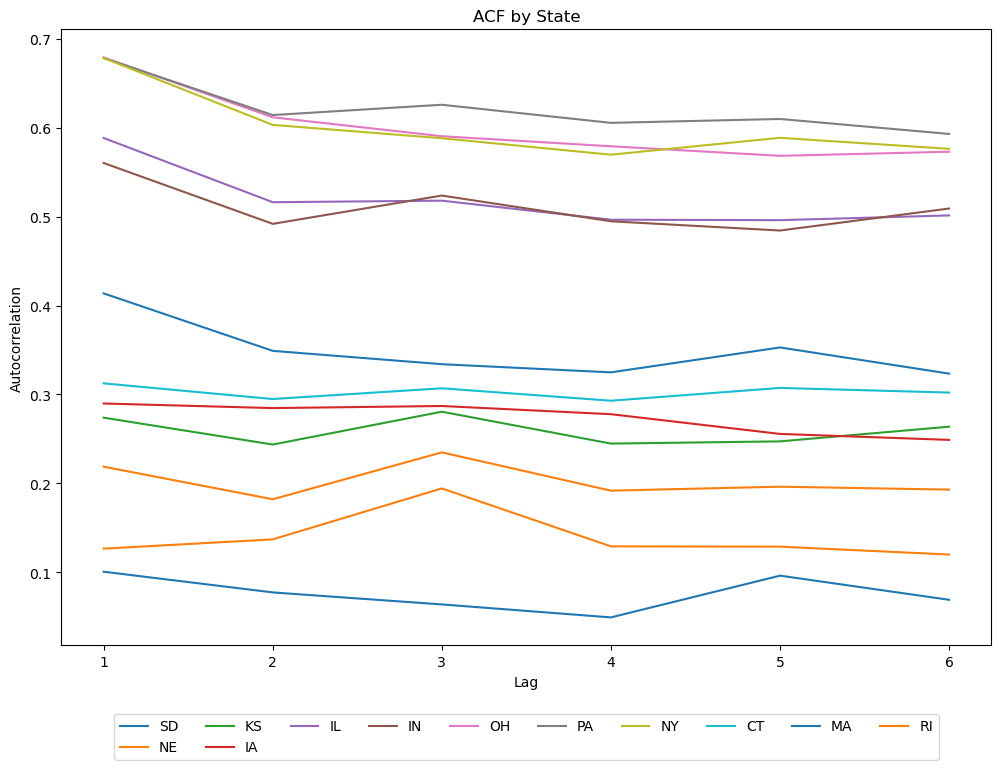

In [7]:
acf_results = {}
states_list = ["SD", "NE", "KS", "IA", "IL", "IN", "OH", "PA", "NY", "CT", "MA", "RI"]

for state in states_list: 
    state_filter = data_grouped["Shipping Address State"] == state # Create subset for only one state
    df_one_state = data_grouped[state_filter]
    acf_values = acf(df_one_state["Revenue"], nlags=6)
    acf_results[state] = acf_values

# Create a plot
plt.figure(figsize=(12, 8))

# Plot ACF for each state
for state, acf_values in acf_results.items():
    plt.plot(range(1, len(acf_values)), acf_values[1:], label=state)

plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('ACF by State')
plt.legend(ncol=10, loc='upper center', bbox_to_anchor=(0.5, -0.1))

# Testing the weather Heterogeneity of the US states

In [10]:
weather_df = pd.read_csv("data/Weather_data.csv")

weather_df["date"] = pd.to_datetime(weather_df["date"], format='%Y%m%d')
weather_df.info

<bound method DataFrame.info of         Unnamed: 0 st_abb  st_code       date stability     ppt    tmax  \
0                1     AL        1 2017-01-01    stable  25.626  13.849   
1                2     AL        1 2017-01-02    stable  40.827  17.970   
2                3     AL        1 2017-01-03    stable  54.893  19.500   
3                4     AL        1 2017-01-04    stable   0.048  19.158   
4                5     AL        1 2017-01-05    stable   0.002  11.202   
...            ...    ...      ...        ...       ...     ...     ...   
122683      122684     WY       56 2023-12-27    stable   0.529  -1.229   
122684      122685     WY       56 2023-12-28    stable   0.013   1.189   
122685      122686     WY       56 2023-12-29    stable   0.034   2.975   
122686      122687     WY       56 2023-12-30    stable   0.035   4.424   
122687      122688     WY       56 2023-12-31    stable   0.003   5.269   

          tmin    tavg  dday_a0C  ...  dday_a25C  dday_a29C  dday_a

In [11]:
df_Cfa_weather = weather_df[weather_df["st_abb"].isin(["SD", "NE", "KS", "IA", "IL", "IN", "OH", "PA", "NY", "CT", "MA", "RI"])]
df_Cfa_weather

,Unnamed: 0,st_abb,st_code,date,stability,ppt,tmax,tmin,tavg,dday_a0C,...,dday_a25C,dday_a29C,dday_a30C,dday_a31C,dday_a32C,dday_a33C,dday_a34C,dday_b15C,dday_b18C,dday_b21C
155,156,CT,9,2017-01-01,stable,2.143,5.194,-4.490,0.352,1.782,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.648,17.648,20.648
156,157,CT,9,2017-01-02,stable,0.000,6.312,-4.929,0.692,2.185,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.308,17.308,20.308
157,158,CT,9,2017-01-03,stable,3.250,2.954,-3.563,-0.304,0.937,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.304,18.304,21.304
158,159,CT,9,2017-01-04,stable,15.914,5.091,2.511,3.801,3.801,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.199,14.199,17.199
159,160,CT,9,2017-01-05,stable,0.060,8.142,-3.973,2.084,3.128,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.916,15.916,18.916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122404,122405,SD,46,2023-12-27,stable,5.757,0.080,-3.691,-1.806,0.072,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.806,19.806,22.806
122405,122406,SD,46,2023-12-28,stable,0.562,1.432,-5.562,-2.065,0.347,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.065,20.065,23.065
122406,122407,SD,46,2023-12-29,stable,0.005,2.276,-8.717,-3.220,0.569,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.220,21.220,24.220
122407,122408,SD,46,2023-12-30,stable,0.001,5.010,-5.897,-0.443,1.607,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.443,18.443,21.443


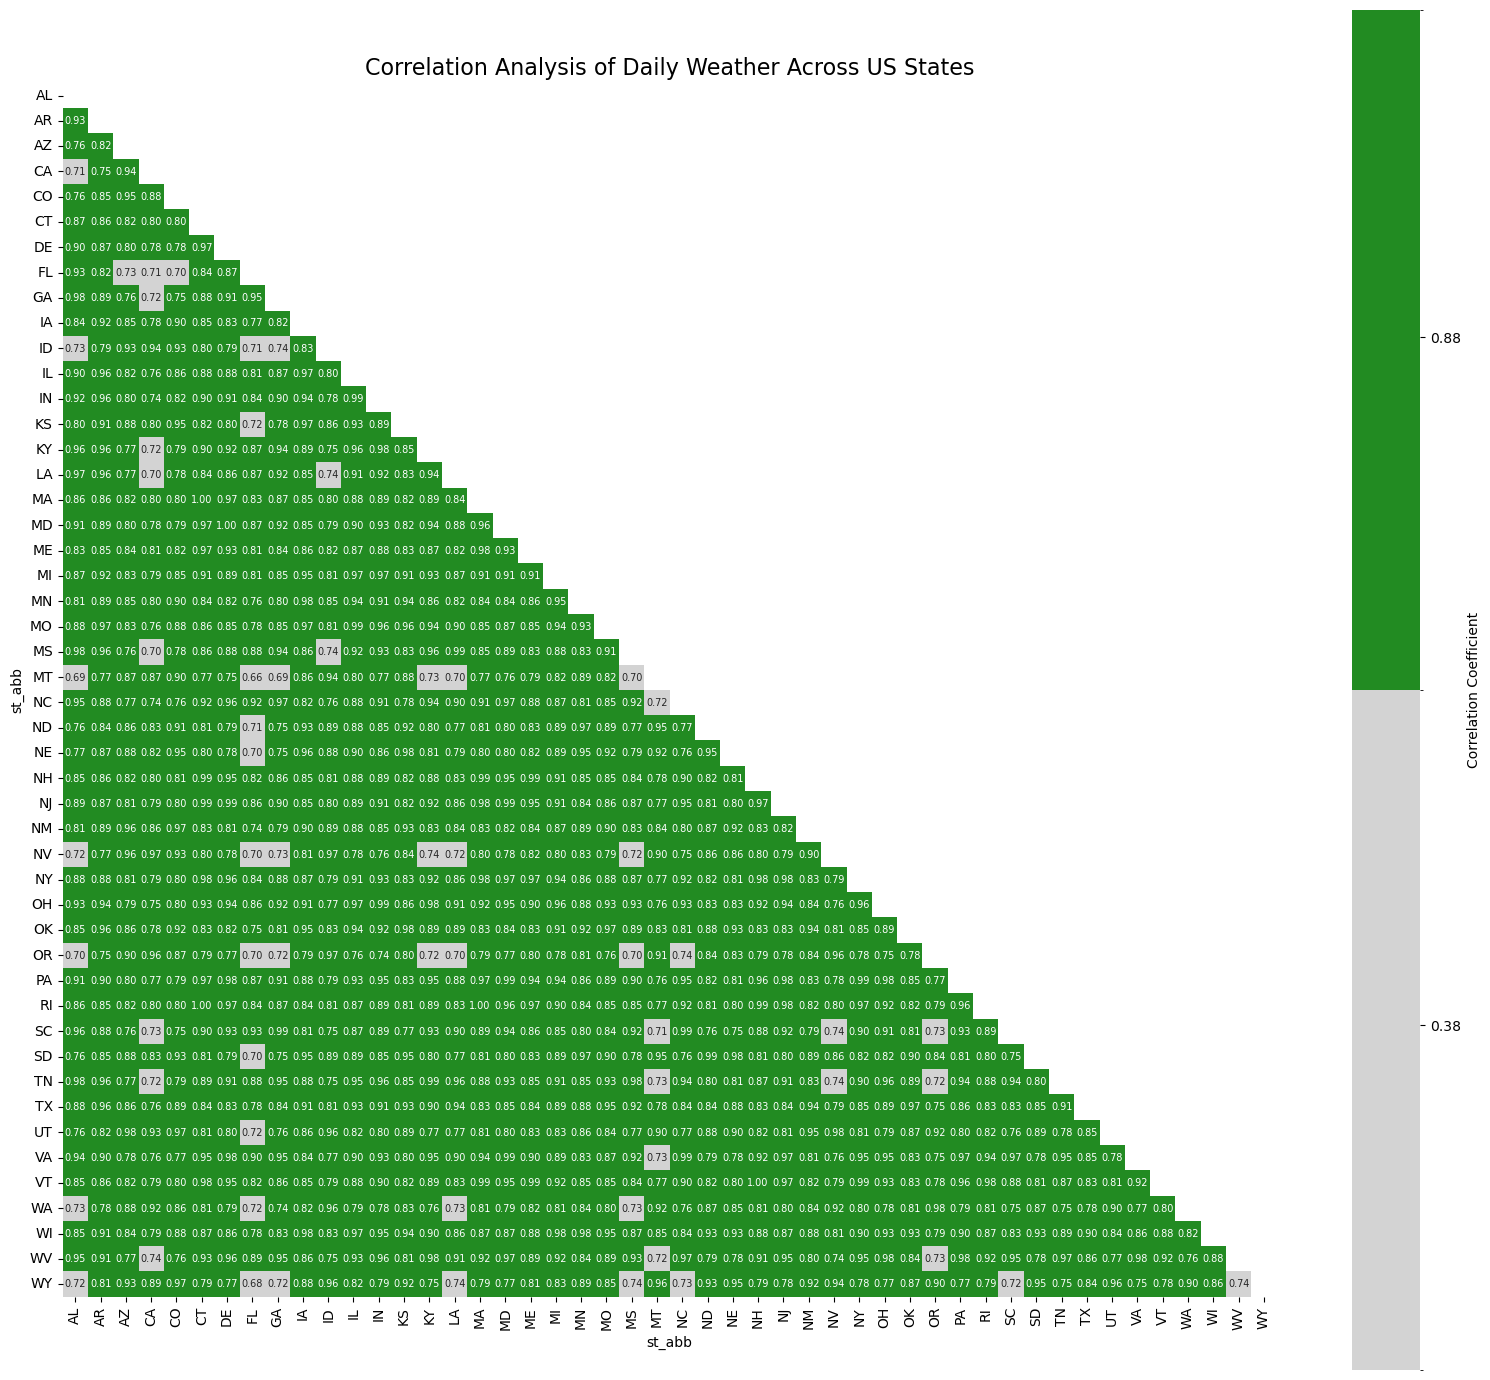

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

pivot_df = weather_df.pivot(index='date', columns='st_abb', values='tavg')
corr_matrix = pivot_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Step 4: Set up the figure
plt.figure(figsize=(16, 14))

# Create a custom colormap with just two colors
# Light grey for values < 0.75, green for values >= 0.75
cmap = mcolors.ListedColormap(['lightgrey', 'forestgreen'])
boundaries = [0, 0.74, 1]
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

# Step 5: Create the heatmap with the custom colormap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', mask=mask,
            cmap=cmap, norm=norm,
            cbar_kws={'label': 'Correlation Coefficient',
                     'ticks': [0.375, 0.875],
                     'format': '%.2f'},
            annot_kws={"size": 7}, square=True)

# Update the custom legend to match the new colors
"""custom_legend = [
    plt.Rectangle((0, 0), 1, 1, fc='lightgrey', edgecolor='black'),
    plt.Rectangle((0, 0), 1, 1, fc='forestgreen', edgecolor='black')
]"""
"""
plt.legend(custom_legend, ['ρ < 0.75', 'ρ ≥ 0.75'], 
           loc='upper right', bbox_to_anchor=(1.15, 0.2))"""

# Step 6: Add labels and title
plt.title('Correlation Analysis of Daily Weather Across US States', fontsize=16)
plt.tight_layout()
plt.show()

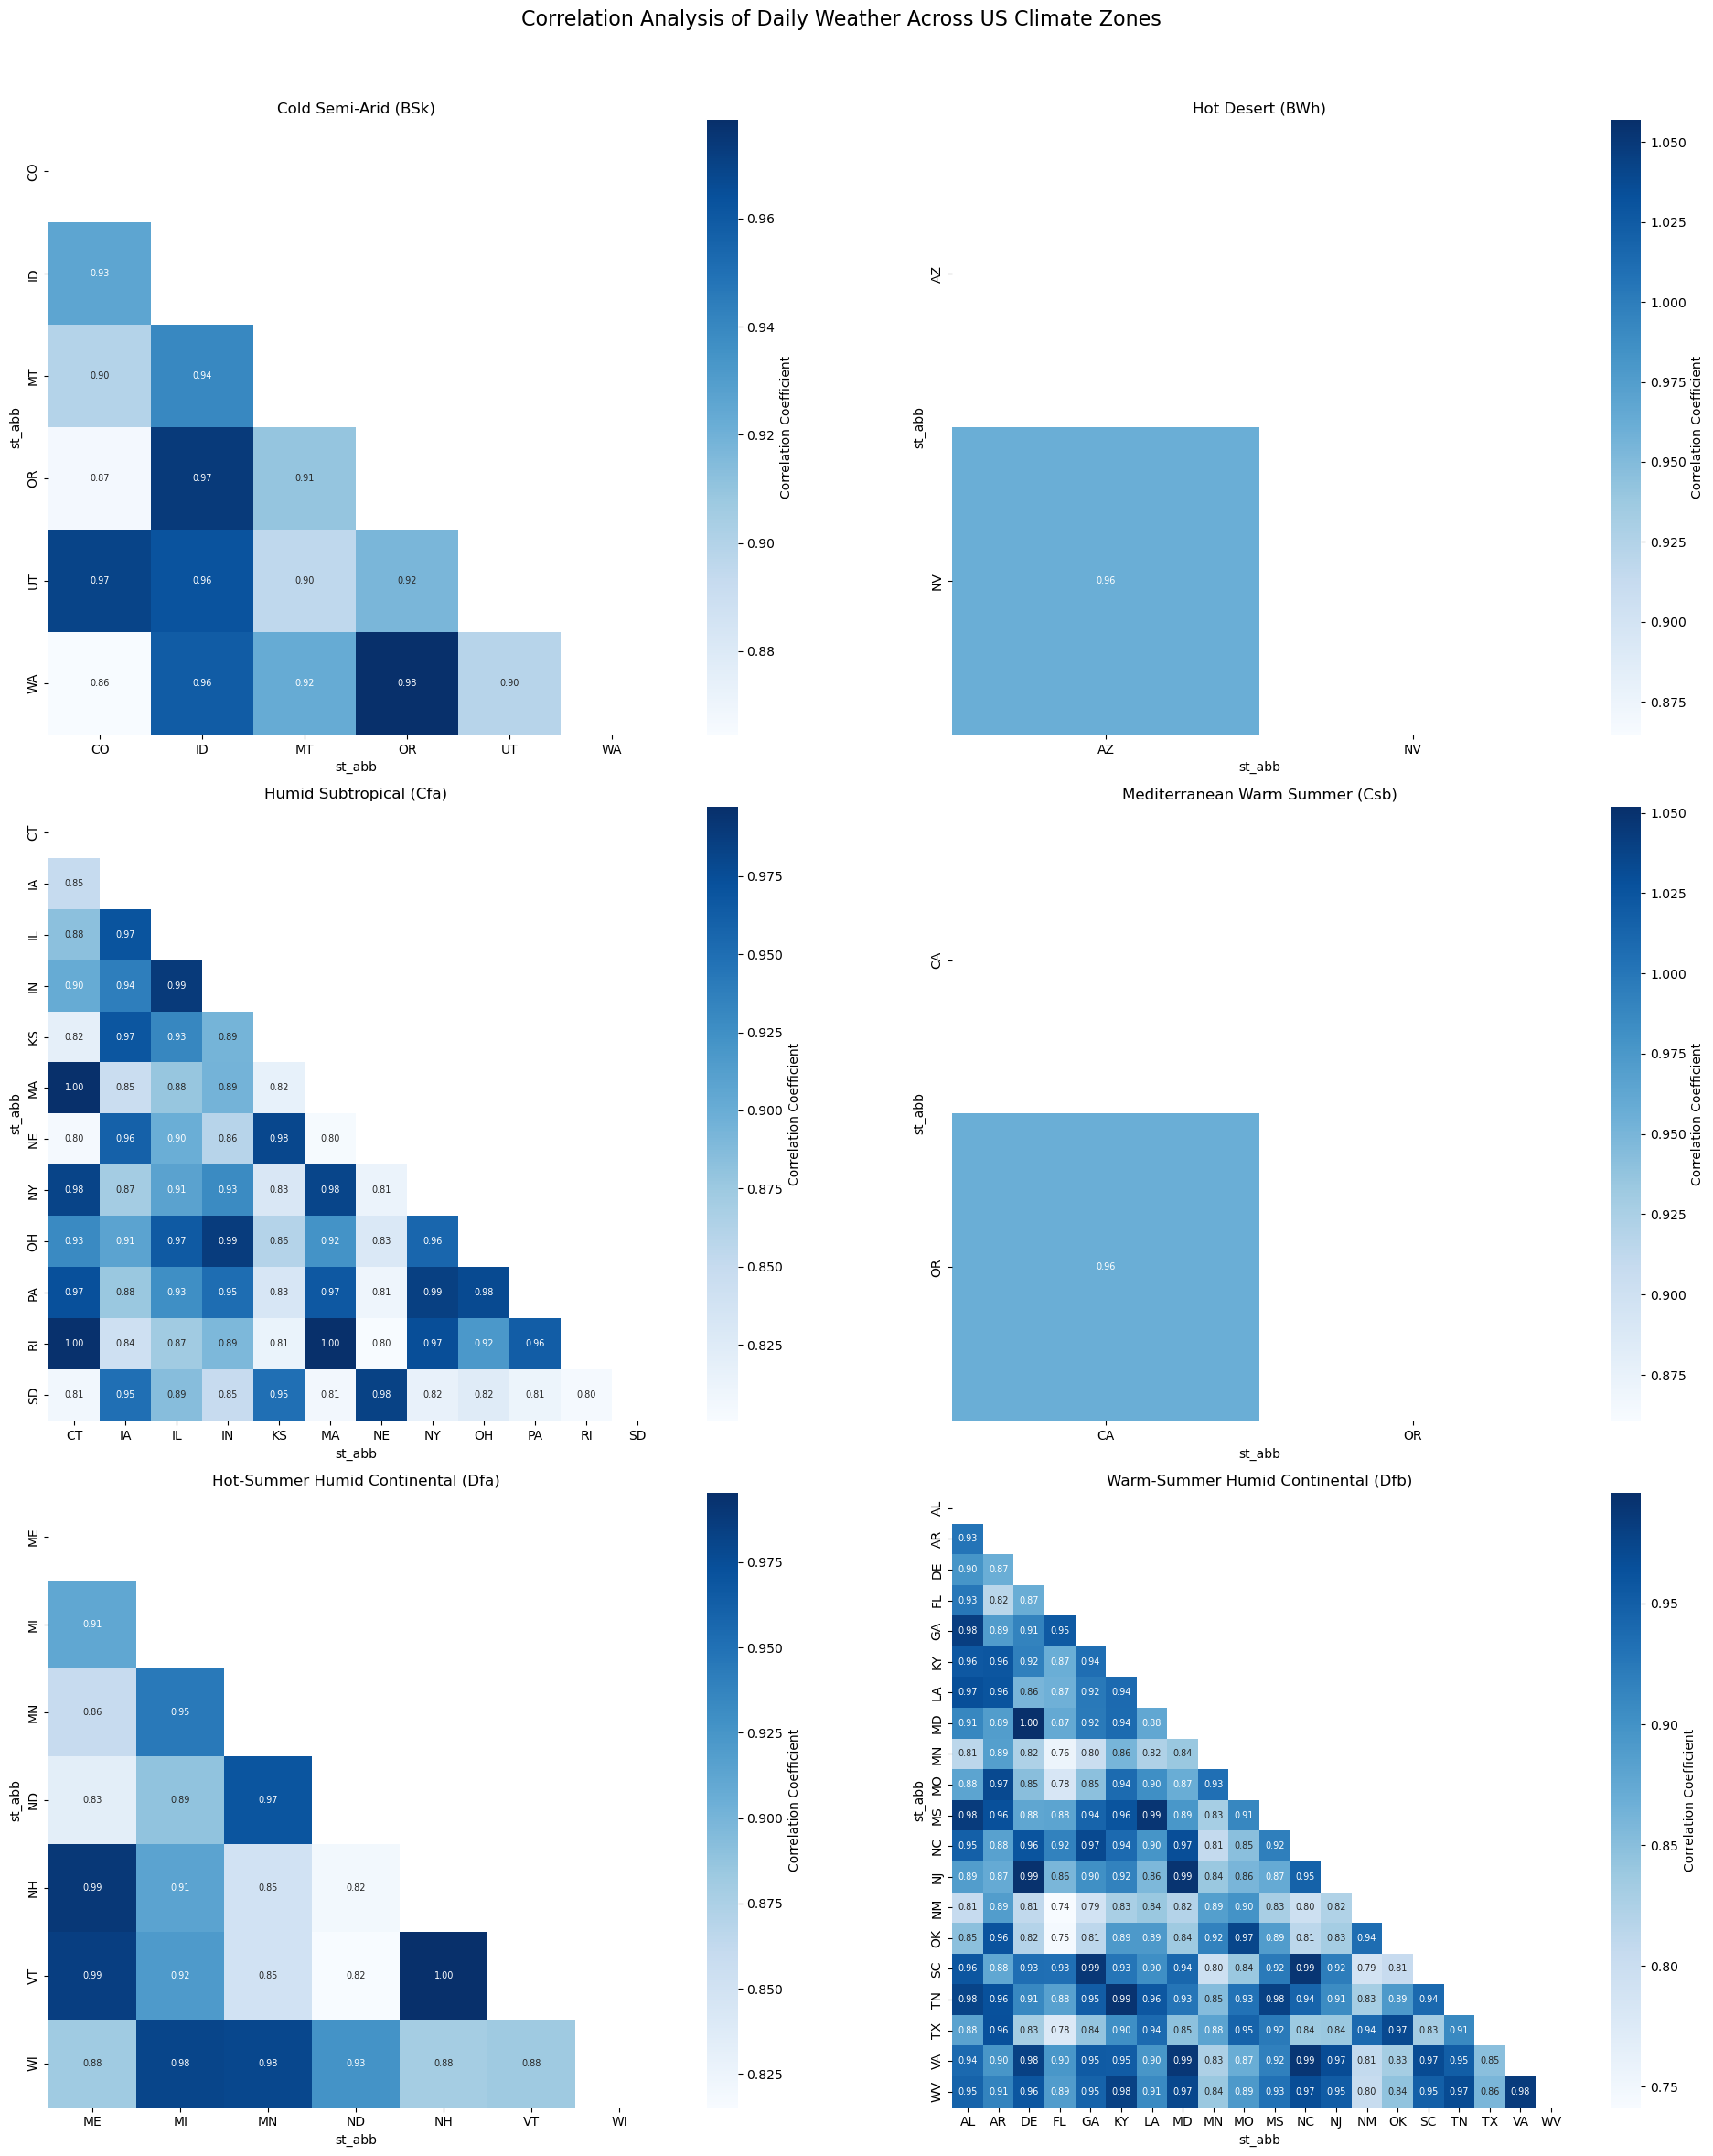

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

# Define the states belonging to each Köppen climate classification
climate_zones = {
    'BSk': ['WA', 'OR', 'MT', 'ID', 'UT', 'CO'],  # Cold semi-arid
    'BWh': ['NV', 'AZ'],  # Hot desert
    #'BWk': ['CA'],        # Cold desert
    'Cfa': ['SD', 'NE', 'KS', 'IA', 'IL', 'IN', 'OH', 'PA', 'NY', 'CT', 'MA', 'RI'],  # Humid subtropical
    #'Csa': ['CA'],        # Mediterranean (hot summer)
    'Csb': ['CA', 'OR'],  # Mediterranean (warm summer)
    'Dfa': ['MN', 'WI', 'MI', 'ME', 'NH', 'VT', 'ND'],  # Hot-summer humid continental
    'Dfb': ['MN', 'NM', 'TX', 'OK', 'AR', 'MO', 'TN', 'KY', 'WV', 'VA', 'NC', 'SC', 'GA', 'AL', 'MS', 'LA', 'DE', 'MD', 'NJ', 'FL']  # Warm-summer humid continental
}

# Function to create correlation matrix for a climate zone
def create_correlation_matrix(weather_df, zone_states, zone_name):
    # Filter data for states in the climate zone
    df_zone = weather_df[weather_df["st_abb"].isin(zone_states)]
    
    # Create pivot table
    pivot_df = df_zone.pivot(index='date', columns='st_abb', values='tavg')
    
    # Calculate correlation matrix
    corr_matrix = pivot_df.corr()
    
    # Create mask for upper triangle
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # Create a figure
    fig = plt.figure(figsize=(10, 8))
    
    # Create heatmap with a blue color palette (removed the green coloring)
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', mask=mask,
                cmap="Blues",  # Changed to a standard blue colormap
                cbar_kws={'label': 'Correlation Coefficient'},
                annot_kws={"size": 7}, square=True)
    
    # Add title
    plt.title(f'Correlation Analysis for {zone_name} Climate Zone', fontsize=14)
    plt.tight_layout()
    
    return fig, corr_matrix

# Function to create all correlation matrices
def create_all_matrices(weather_df):
    # Create figure for all plots
    fig = plt.figure(figsize=(20, 24))
    gs = GridSpec(3, 2, figure=fig)
    
    # Define zone titles with descriptions
    zone_titles = {
        'BSk': 'Cold Semi-Arid (BSk)',
        'BWh': 'Hot Desert (BWh)',
        'BWk': 'Cold Desert (BWk)',
        'Cfa': 'Humid Subtropical (Cfa)',
        'Csa': 'Mediterranean Hot Summer (Csa)',
        'Csb': 'Mediterranean Warm Summer (Csb)',
        'Dfa': 'Hot-Summer Humid Continental (Dfa)',
        'Dfb': 'Warm-Summer Humid Continental (Dfb)'
    }
    
    # Create correlation matrix for each climate zone
    for i, (zone, states) in enumerate(climate_zones.items()):
        # Check if there are enough states in this zone
        if len(states) < 2:
            print(f"Skipping {zone} - not enough states for correlation")
            continue
            
        # Get states that actually exist in the dataset
        available_states = set(states).intersection(set(weather_df['st_abb'].unique()))
        if len(available_states) < 2:
            print(f"Skipping {zone} - not enough states with data")
            continue
        
        # Create subplot
        ax = fig.add_subplot(gs[i // 2, i % 2])
        
        # Filter data for states in the climate zone
        df_zone = weather_df[weather_df["st_abb"].isin(available_states)]
        
        # Create pivot table
        pivot_df = df_zone.pivot(index='date', columns='st_abb', values='tavg')
        
        # Calculate correlation matrix
        corr_matrix = pivot_df.corr()
        
        # Create mask for upper triangle
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        
        # Create heatmap with a blue color palette (removed the green coloring)
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', mask=mask,
                    cmap="Blues",  # Changed to a standard blue colormap
                    cbar_kws={'label': 'Correlation Coefficient'},
                    annot_kws={"size": 7}, square=True, ax=ax)
        
        # Add title
        ax.set_title(zone_titles[zone], fontsize=12)
    
    # Add overall title
    plt.suptitle('Correlation Analysis of Daily Weather Across US Climate Zones', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Make room for the suptitle
    
    return fig

# Example usage:
fig = create_all_matrices(weather_df)
plt.show()

# Alternatively, you can create individual matrices:
# For example:
# fig_cfa, corr_cfa = create_correlation_matrix(weather_df, climate_zones['Cfa'], 'Humid Subtropical (Cfa)')
# plt.show()

<Axes: xlabel='st_abb', ylabel='st_abb'>

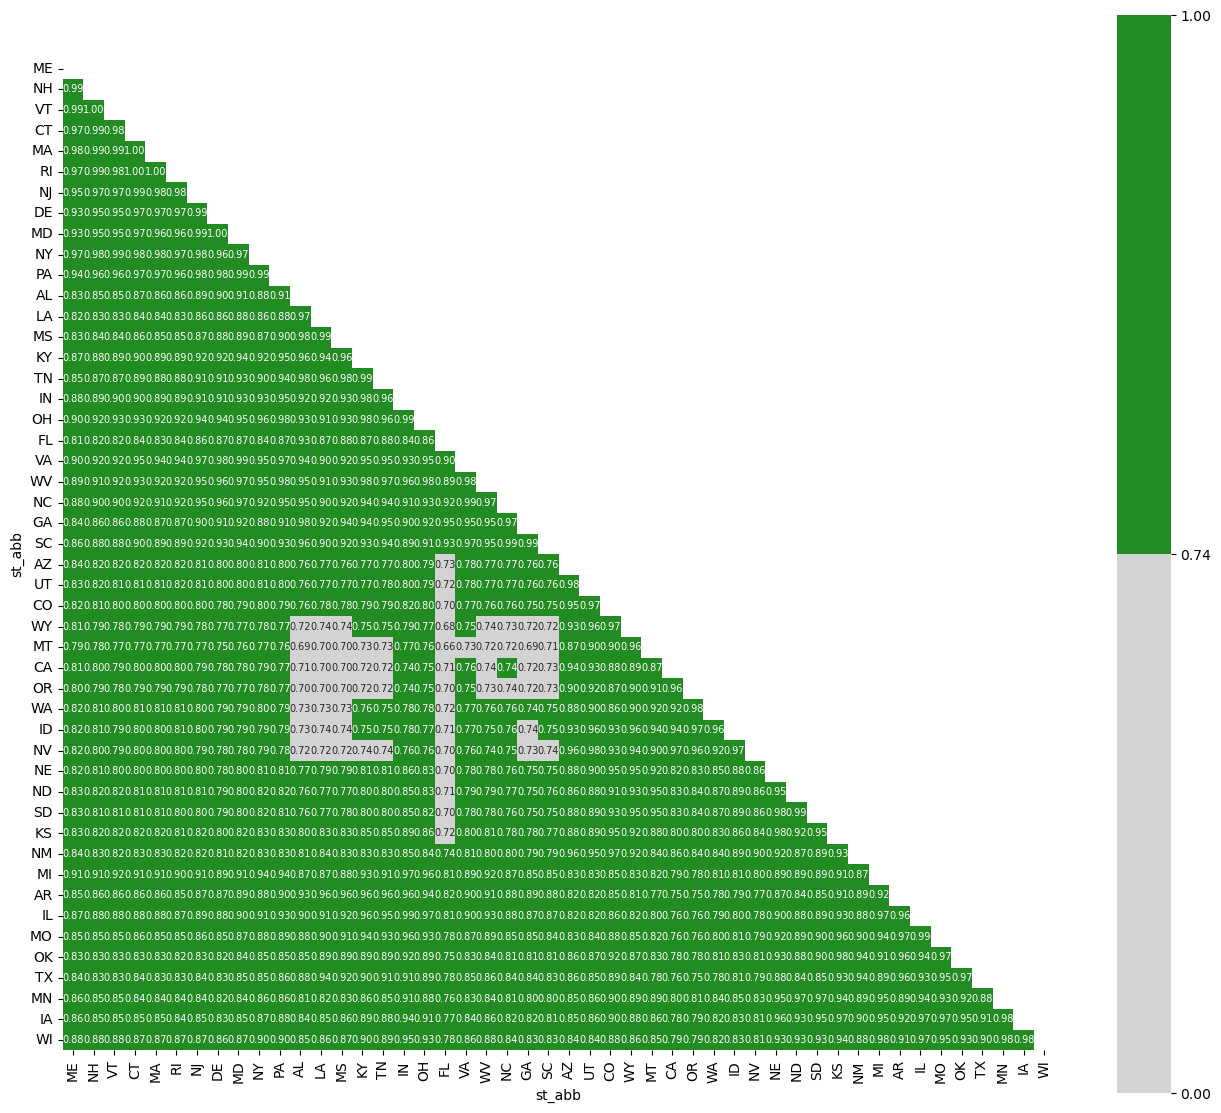

In [14]:
import scipy.cluster.hierarchy as sch

# Compute linkage matrix for hierarchical clustering
linkage = sch.linkage(corr_matrix, method='ward')

# Get the order of states based on clustering
dendro = sch.dendrogram(linkage, no_plot=True)
cluster_order = dendro['leaves']

# Reorder correlation matrix
ordered_corr = corr_matrix.iloc[cluster_order, cluster_order]

# Create heatmap with clustered data
plt.figure(figsize=(16, 14))
sns.heatmap(ordered_corr, annot=True, fmt='.2f', mask=np.triu(np.ones_like(ordered_corr)),
            cmap=cmap, norm=norm, annot_kws={"size": 7}, square=True)

Shapefile columns: ['featurecla', 'scalerank', 'adm1_code', 'diss_me', 'iso_3166_2', 'wikipedia', 'iso_a2', 'adm0_sr', 'name', 'name_alt', 'name_local', 'type', 'type_en', 'code_local', 'code_hasc', 'note', 'hasc_maybe', 'region', 'region_cod', 'provnum_ne', 'gadm_level', 'check_me', 'datarank', 'abbrev', 'postal', 'area_sqkm', 'sameascity', 'labelrank', 'name_len', 'mapcolor9', 'mapcolor13', 'fips', 'fips_alt', 'woe_id', 'woe_label', 'woe_name', 'latitude', 'longitude', 'sov_a3', 'adm0_a3', 'adm0_label', 'admin', 'geonunit', 'gu_a3', 'gn_id', 'gn_name', 'gns_id', 'gns_name', 'gn_level', 'gn_region', 'gn_a1_code', 'region_sub', 'sub_code', 'gns_level', 'gns_lang', 'gns_adm1', 'gns_region', 'min_label', 'max_label', 'min_zoom', 'wikidataid', 'name_ar', 'name_bn', 'name_de', 'name_en', 'name_es', 'name_fr', 'name_el', 'name_hi', 'name_hu', 'name_id', 'name_it', 'name_ja', 'name_ko', 'name_nl', 'name_pl', 'name_pt', 'name_ru', 'name_sv', 'name_tr', 'name_vi', 'name_zh', 'ne_id', 'name_he'

c:\Users\morit\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


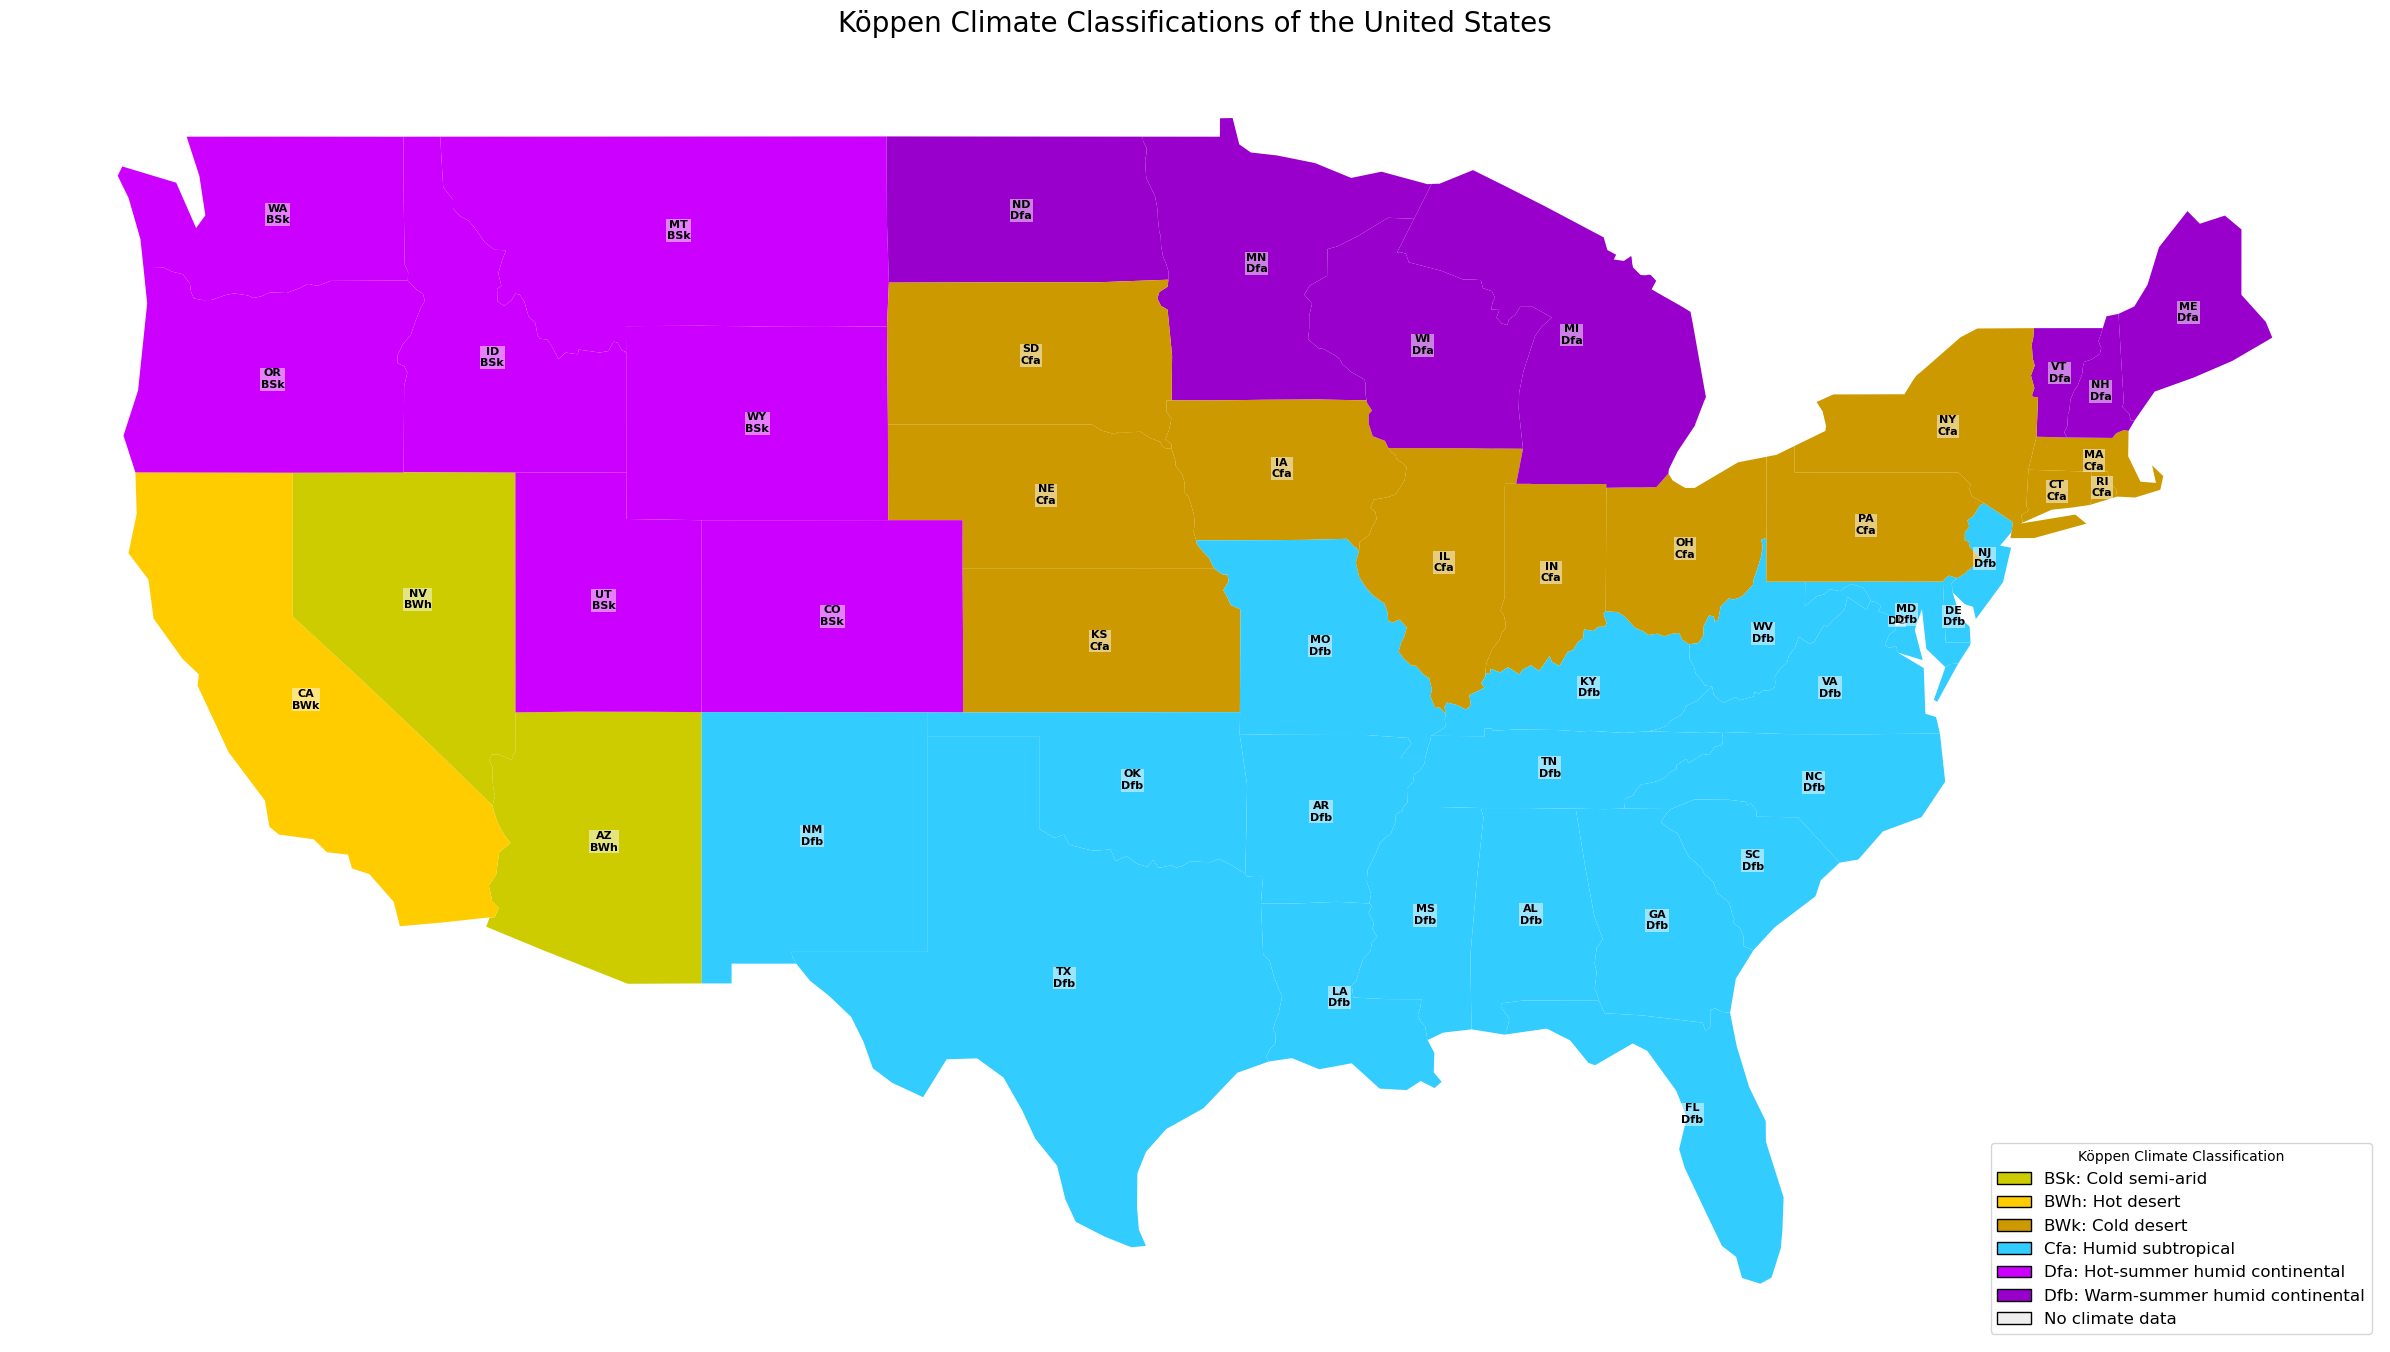

In [15]:

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

climate_df = pd.read_csv("data/koeppen_states")

# Load US states shapefile
try:
    usa = gpd.read_file('./data/Map_USA/ne_110m_admin_1_states_provinces.shp')
    
    # Print shapefile columns to debug
    print("Shapefile columns:", usa.columns.tolist())
    
    # Ensure the 'postal' column exists
    if 'postal' not in usa.columns:
        print("Warning: 'postal' column not found in shapefile. Available columns:", usa.columns.tolist())
        # Try to find a suitable alternative column that might contain state codes
        if 'iso_3166_2' in usa.columns:
            print("Using 'iso_3166_2' column instead")
            usa['postal'] = usa['iso_3166_2'].str.replace('US-', '')
        elif 'postal_code' in usa.columns:
            print("Using 'postal_code' column instead")
            usa['postal'] = usa['postal_code']
        elif 'state_code' in usa.columns:
            print("Using 'state_code' column instead")
            usa['postal'] = usa['state_code']
        elif 'STUSPS' in usa.columns:
            print("Using 'STUSPS' column instead")
            usa['postal'] = usa['STUSPS']
        else:
            print("No suitable column found for state abbreviations")
            # Create a simple mapping for demonstration if needed
            usa['postal'] = usa.index.astype(str)
except Exception as e:
    print(f"Error loading shapefile: {e}")

# Remove Alaska and Hawaii for contiguous US map
usa_continental = usa[~usa['postal'].isin(['AK', 'HI'])]

# Convert state codes 
usa_continental['state'] = usa_continental['postal']  # Using the postal column for state abbreviations

# Merge with climate data
usa_climate = usa_continental.merge(climate_df[['state_abbrev', 'koppen_code', 'climate_description']], 
                                   left_on='state', right_on='state_abbrev', how='left')

# Print debug info about the merge
print(f"Total states in shapefile: {len(usa_continental)}")
print(f"Total states after merge: {len(usa_climate)}")
print(f"States with NaN Köppen codes: {usa_climate[usa_climate['koppen_code'].isna()]['state'].tolist()}")

# Create a color dictionary for Köppen codes
# Colors grouped by major climate type (first letter)
koppen_colors = {
    # A - Tropical climates (green)
    'Af': '#006600',  # Tropical rainforest - dark green
    
    # B - Dry climates (yellows/browns)
    'BWh': '#FFCC00',  # Hot desert - bright yellow
    'BWk': '#CC9900',  # Cold desert - tan
    'BSk': '#CCCC00',  # Cold semi-arid - yellow-tan
    
    # C - Temperate climates (blues)
    'Cfa': '#33CCFF',  # Humid subtropical - light blue
    'Csa': '#0066CC',  # Mediterranean hot summer - medium blue
    'Csb': '#3399FF',  # Mediterranean warm summer - blue
    
    # D - Continental climates (purples)
    'Dfa': '#CC00FF',  # Hot-summer humid continental - light purple
    'Dfb': '#9900CC',  # Warm-summer humid continental - medium purple
    'Dfc': '#660099',  # Subarctic - dark purple
}

# Create figure
fig = plt.figure(figsize=(24, 14))
ax = fig.add_subplot(111)

# Fix for NaN values in Köppen codes
# Get only valid Köppen codes (non-NaN)
valid_koppen_codes = [code for code in usa_climate['koppen_code'].unique() if pd.notna(code)]

# Plot the map with Köppen codes
if len(valid_koppen_codes) > 0:
    usa_climate.plot(column='koppen_code', 
                    categorical=True,
                    cmap=ListedColormap([koppen_colors[code] for code in valid_koppen_codes]),
                    ax=ax,
                    legend=False,
                    missing_kwds={'color': '#EEEEEE'})  # Light gray for missing data
else:
    # Fallback if no valid Köppen codes are found
    usa_climate.plot(ax=ax, color='lightgrey')
    print("Warning: No valid Köppen codes found in the merged data")

# Create a custom legend for valid Köppen codes
legend_elements = []
for code in sorted(valid_koppen_codes):
    description = climate_df[climate_df['koppen_code']==code]['climate_description'].iloc[0]
    legend_elements.append(
        Patch(facecolor=koppen_colors[code], 
              edgecolor='black',
              label=f"{code}: {description}")
    )

# Add legend element for missing data if needed
states_with_nan = usa_climate[usa_climate['koppen_code'].isna()]['state'].tolist()
if len(states_with_nan) > 0:
    legend_elements.append(
        Patch(facecolor='#EEEEEE', 
              edgecolor='black',
              label='No climate data')
    )

ax.legend(handles=legend_elements, 
          title='Köppen Climate Classification',
          loc='lower right', 
          fontsize=12)

# Add state labels
for idx, row in usa_climate.iterrows():
    centroid = row.geometry.centroid
    label_text = f"{row['state']}"
    if pd.notna(row['koppen_code']):
        label_text += f"\n{row['koppen_code']}"
    
    ax.text(centroid.x, centroid.y,
            label_text,
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=8,
            fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0.5))

plt.title('Köppen Climate Classifications of the United States', fontsize=20, pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()


The positions represent similarity in weather patterns over time (correlation)

The colors represent distinct climate categories based on average temperature and precipitation

For example MD and PA might be hot and cold, respectivly but there behaviour for temperature changes is very similar, which makes it reasonable to consider them in one category for our analysis.

TODO: 
Change names for Continetal Variable Patterns and Humid Costal Flucataions